# Captura de Señal PPG desde Reloj Pinetime

Este notebook permite capturar datos crudos de fotopletismografía (PPG) desde un reloj Pinetime vía Bluetooth Low Energy (BLE) con el nuevo método propuesto. Los datos se guardan en formato CSV junto con metadata para su posterior procesamiento con modelos de machine learning.

## Características principales

- **Conexión BLE**: Comunicación directa con el reloj Pinetime
- **Captura en tiempo real**: Muestreo a 25 Hz con visualización en vivo
- **Procesamiento básico**: Filtrado bandpass y detección de picos para estimación de frecuencia cardíaca

## Flujo de trabajo

1. Conectar al dispositivo BLE
2. Iniciar captura y guardar datos
3. Detener captura

## Librerias e Imports

In [1]:
pip install pandas numpy scipy ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import hrs_analysis_tools
import importlib
importlib.reload(hrs_analysis_tools)

<module 'hrs_analysis_tools' from 'c:\\Users\\andre\\Downloads\\pinetime\\pruebas\\ppg_analysis\\hrs_analysis_tools.py'>

# Capturar y Guardar Plots TEMPORAAAL

In [42]:
%matplotlib inline

import asyncio
import struct
import time
import os
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
from IPython import display
from bleak import BleakClient, BleakScanner
from scipy.signal import butter, filtfilt

# =============================================================================
# Configuración
# =============================================================================

CHAR_UUID = "b5f90001-8456-4c84-a6b9-5f95a2f2f1f0"

USE_ADDRESS = True
ADDRESS = "f2:2b:66:04:27:68"
DEVICE_NAME = "InfiniTime"

FS = 25.0
DT = 1.0 / FS

WINDOW_SECONDS = 10
N_WINDOW = int(FS * WINDOW_SECONDS)

REFRESH_SECONDS = 0.2

# =============================================================================
# Salidas
# =============================================================================

timestamp = str(int(time.time()))
os.makedirs("data", exist_ok=True)

raw_file = open(f"data/{timestamp}_hrs_raw.csv", "w")
time_file = open(f"data/{timestamp}_time.csv", "w")


raw_file.flush()
time_file.flush()

# =============================================================================
# BLE utils
# =============================================================================

async def resolve_address():
    if USE_ADDRESS:
        print(f"Usando address fija: {ADDRESS}")
        return ADDRESS

    print("Escaneando BLE...")
    devices = await BleakScanner.discover(timeout=8)

    for dev in devices:
        if dev.name == DEVICE_NAME:
            print(f"Encontrado: {dev.name} -> {dev.address}")
            return dev.address

    raise RuntimeError("No se encontró el dispositivo")

# =============================================================================
# Filtro
# =============================================================================

def bandpass_filter(signal, lowcut=0.5, highcut=4.0, fs=25.0, order=3):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    return filtfilt(b, a, signal)

# =============================================================================
# MAIN
# =============================================================================

async def run_ppg():
    address = await resolve_address()
    print(f"Conectando a: {address}")

    t_values = deque(maxlen=5000)
    hrs_values = deque(maxlen=5000)

    first_counter = None
    last_counter = None
    saved_samples = 0

    def notification_handler(_sender, data: bytearray):
        nonlocal first_counter, last_counter, saved_samples

        if len(data) != 8:
            print(f"Paquete raro: {data.hex()}")
            return

        sample_counter, hrs_raw, _ = struct.unpack("<IHH", data)

        if first_counter is None:
            first_counter = sample_counter

        if last_counter is not None and sample_counter != last_counter + 1:
            print(f"Salto: esperado {last_counter + 1}, llegó {sample_counter}")

        last_counter = sample_counter

        # Tiempo ideal según fs = 25 Hz
        t_sample = (sample_counter - first_counter) * DT

        # Buffers para visualización
        t_values.append(t_sample)
        hrs_values.append(hrs_raw)

        # Guardado completo en CSV: una fila = un dato
        time_file.write(f"{t_sample:.6f}\n")
        raw_file.write(f"{int(hrs_raw)}\n")

        saved_samples += 1

        # Flush periódico
        if saved_samples % 20 == 0:
            time_file.flush()
            raw_file.flush()

    client = BleakClient(address)

    try:
        await client.connect()
        print(f"Conectado: {client.is_connected}")

        await client.start_notify(CHAR_UUID, notification_handler)
        print("Recibiendo HRS filtrado y guardando CSV...")

        while True:
            display.clear_output(wait=True)
            print(f"Conectado a: {address}")
            print(f"fs = {FS} Hz | Ventana = {WINDOW_SECONDS}s ({N_WINDOW} muestras)")
            print(f"Muestras en buffer: {len(t_values)}")
            print(f"CSV señal: data/{timestamp}_hrs_raw.csv")
            print(f"CSV tiempo: data/{timestamp}_time.csv")
            print("Interrumpe la celda para detener.")

            fig, ax = plt.subplots(figsize=(12, 4))

            if len(hrs_values) >= N_WINDOW:
                tx = np.array(list(t_values)[-N_WINDOW:])
                hy = np.array(list(hrs_values)[-N_WINDOW:])

                hy = hy - np.min(hy)

                try:
                    filtered = bandpass_filter(hy, fs=FS)
                except Exception:
                    filtered = hy

                ax.plot(tx, filtered, label="HRS filtrado")
                ax.set_xlim(tx[0], tx[-1])

                ymin = np.min(filtered)
                ymax = np.max(filtered)
                pad = max(10, (ymax - ymin) * 0.1)
                ax.set_ylim(ymin - pad, ymax + pad)

            elif len(hrs_values) > 0:
                tx = np.array(list(t_values))
                hy = np.array(list(hrs_values))
                hy = hy - np.min(hy)

                ax.plot(tx, hy, label="HRS raw (llenando ventana)")
                ax.set_xlim(tx[0], max(tx[0] + WINDOW_SECONDS, tx[-1] + 1e-6))

                ymin = np.min(hy)
                ymax = np.max(hy)
                pad = max(10, (ymax - ymin) * 0.1) if ymax > ymin else 10
                ax.set_ylim(ymin - pad, ymax + pad)

            else:
                ax.text(
                    0.5, 0.5, "Esperando suficientes muestras...",
                    ha="center", va="center", transform=ax.transAxes
                )

            ax.set_title("InfiniTime - HRS filtrado (25 Hz, 10 s)")
            ax.set_xlabel("Tiempo (s)")
            ax.set_ylabel("Amplitud")
            ax.grid(True)
            ax.legend()

            plt.tight_layout()
            plt.show()
            plt.close(fig)

            await asyncio.sleep(REFRESH_SECONDS)

    finally:
        try:
            await client.stop_notify(CHAR_UUID)
        except Exception:
            pass

        try:
            await client.disconnect()
        except Exception:
            pass

        raw_file.flush()
        time_file.flush()
        raw_file.close()
        time_file.close()

        print("Fin.")
        print(f"Archivo señal: data/{timestamp}_hrs_raw.csv")
        print(f"Archivo tiempo: data/{timestamp}_time.csv")

Conectado a: f2:2b:66:04:27:68
fs = 10.0 Hz | Ventana = 10s (100 muestras)
Muestras en buffer: 314
CSV señal: data/1775688307_hrs_raw.csv
CSV tiempo: data/1775688307_time.csv
Interrumpe la celda para detener.


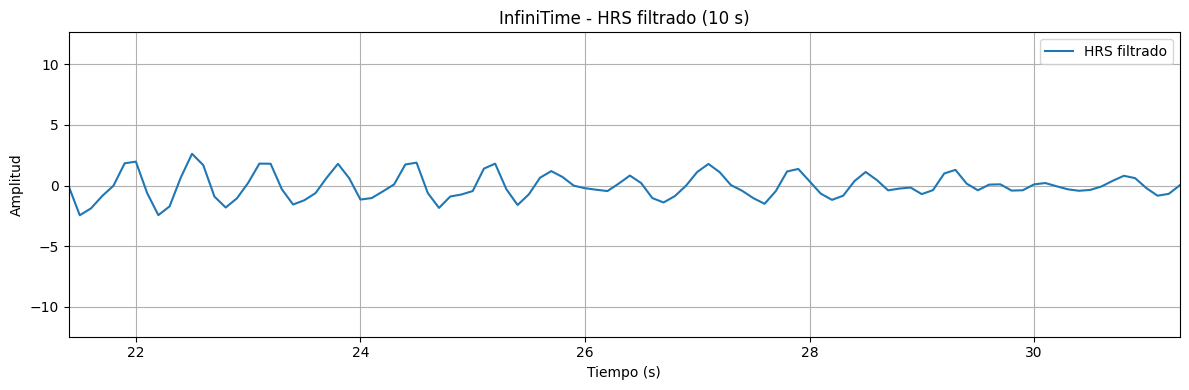

Fin.
Archivo señal: data/1775688307_hrs_raw.csv
Archivo tiempo: data/1775688307_time.csv


CancelledError: 

In [43]:
await run_ppg()